# Salary Prediction

### import libraries

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


In [36]:
df=pd.read_csv('job_salary_prediction_dataset.csv')

In [37]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [38]:
df.tail()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467
249999,Data Analyst,16,Diploma,2,Technology,Medium,UK,No,5,133084


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   job_title         250000 non-null  str  
 1   experience_years  250000 non-null  int64
 2   education_level   250000 non-null  str  
 3   skills_count      250000 non-null  int64
 4   industry          250000 non-null  str  
 5   company_size      250000 non-null  str  
 6   location          250000 non-null  str  
 7   remote_work       250000 non-null  str  
 8   certifications    250000 non-null  int64
 9   salary            250000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 30.7 MB


In [40]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [41]:
df.columns.to_list()

['job_title',
 'experience_years',
 'education_level',
 'skills_count',
 'industry',
 'company_size',
 'location',
 'remote_work',
 'certifications',
 'salary']

In [42]:
print(df.isna().sum())

#fill missing values
for col in df.select_dtypes(include=['str']).columns:
    df[col].fillna(df[col].mode(),inplace=True)



for col in df.select_dtypes(include=['int64','Float64']).columns:
    df[col].fillna(df[col].median
                   (),inplace=True)   

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64


C:\Users\kiran\AppData\Local\Temp\ipykernel_2748\607823728.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].mode(),inplace=True)
C:\Users\kiran\AppData\Local\Temp\ipykernel_2748\607823728.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using a

In [43]:
df.duplicated().sum()


np.int64(0)

#EDA

In [44]:
# univariate analysis
num_cols=df.select_dtypes(include=['int64','Float64']).columns

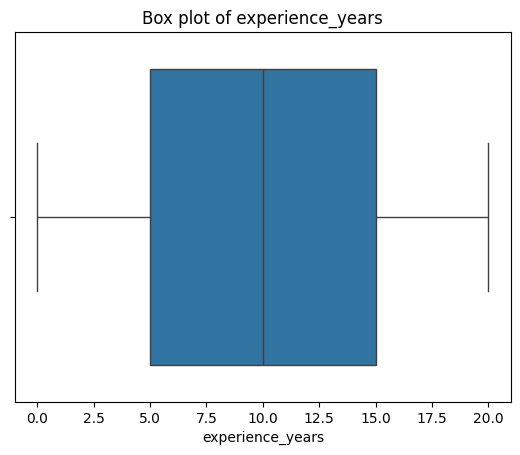

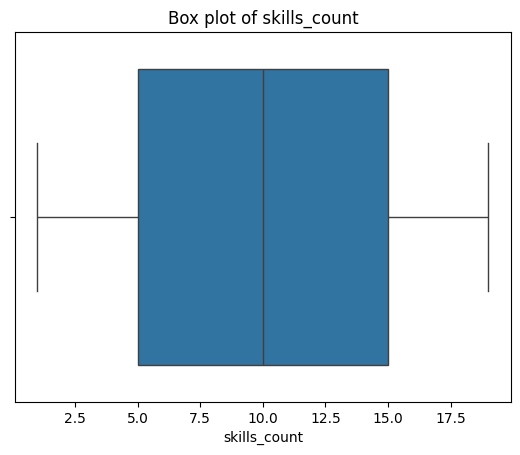

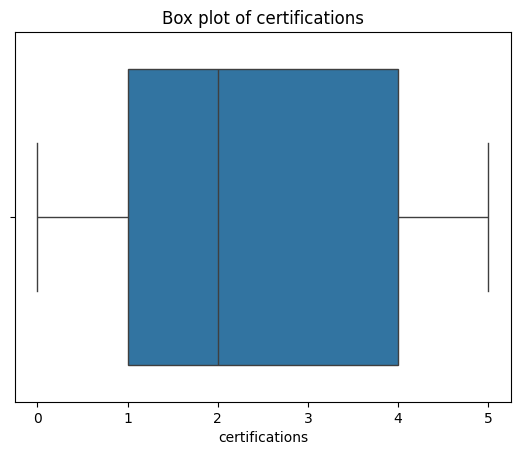

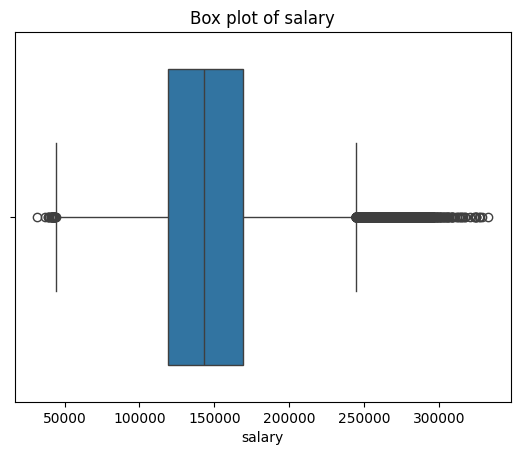

In [45]:
for col in num_cols:
    plt.Figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Box plot of {col}')
    plt.show()

In [46]:
cate_cols=df.select_dtypes(include=['str']).columns

C:\Users\kiran\AppData\Local\Temp\ipykernel_2748\3623055899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],palette='colorblind')  #deep,muted,bright,dark,rainbow,pastel,colorblind


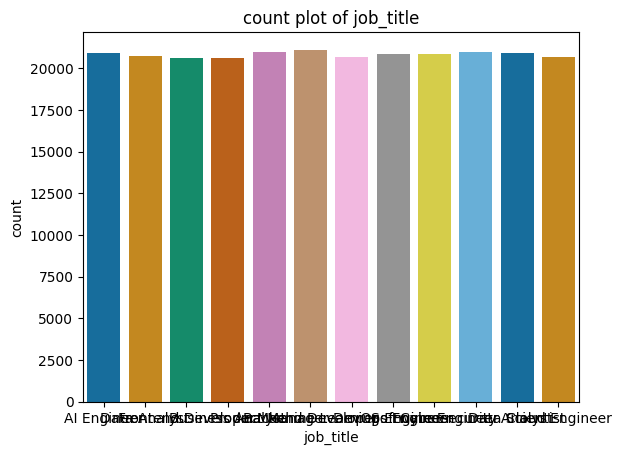

C:\Users\kiran\AppData\Local\Temp\ipykernel_2748\3623055899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],palette='colorblind')  #deep,muted,bright,dark,rainbow,pastel,colorblind


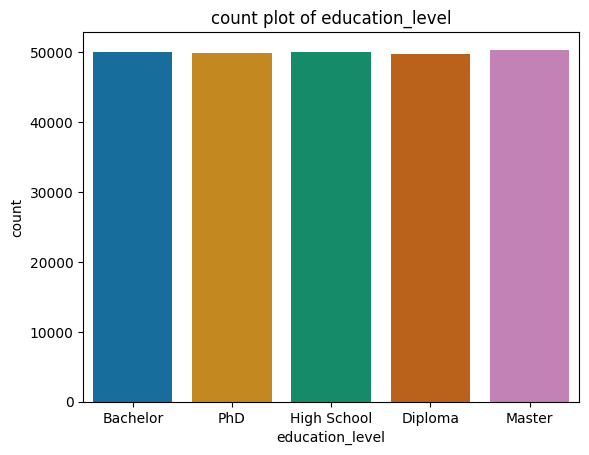

C:\Users\kiran\AppData\Local\Temp\ipykernel_2748\3623055899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],palette='colorblind')  #deep,muted,bright,dark,rainbow,pastel,colorblind


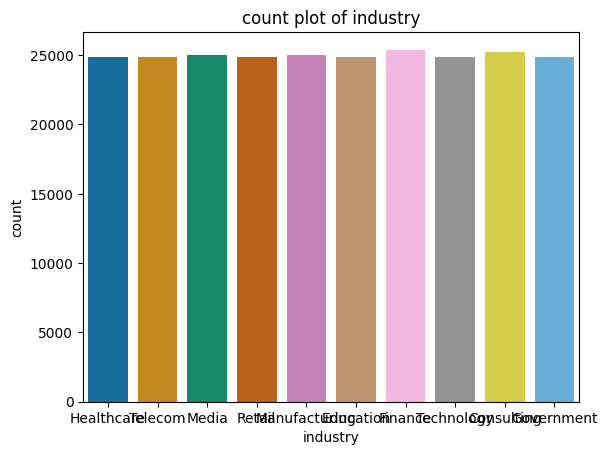

C:\Users\kiran\AppData\Local\Temp\ipykernel_2748\3623055899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],palette='colorblind')  #deep,muted,bright,dark,rainbow,pastel,colorblind


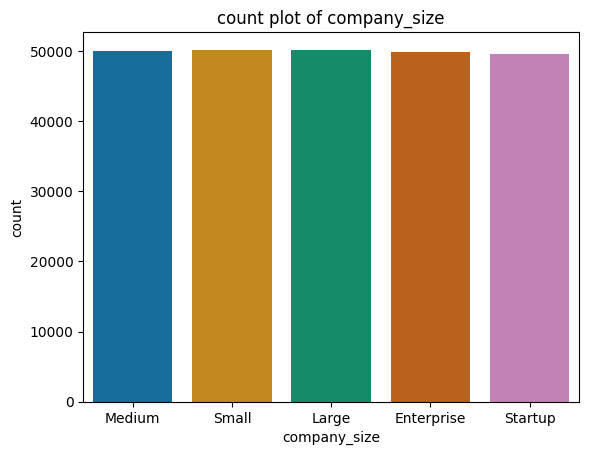

C:\Users\kiran\AppData\Local\Temp\ipykernel_2748\3623055899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],palette='colorblind')  #deep,muted,bright,dark,rainbow,pastel,colorblind


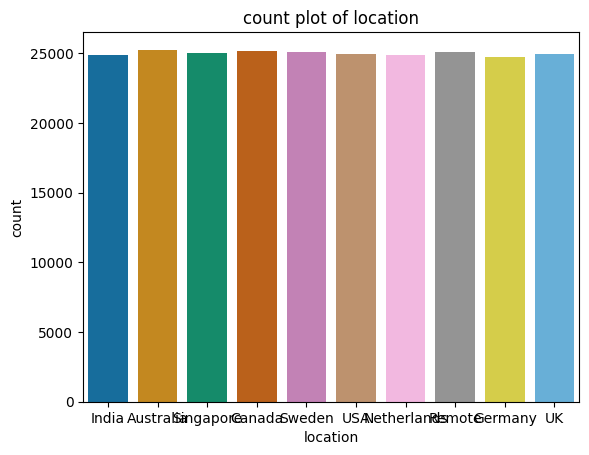

C:\Users\kiran\AppData\Local\Temp\ipykernel_2748\3623055899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],palette='colorblind')  #deep,muted,bright,dark,rainbow,pastel,colorblind


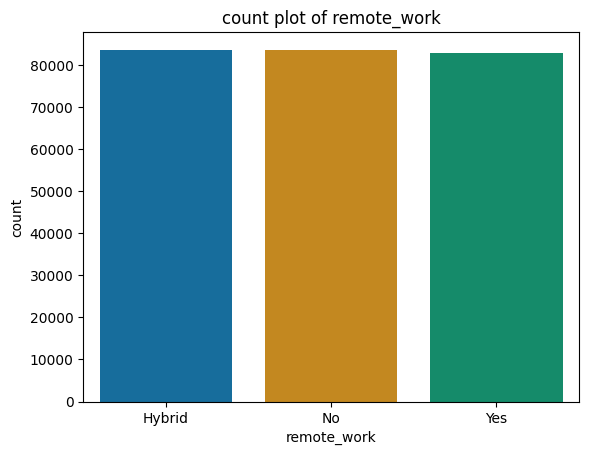

In [47]:
for col in cate_cols:
    plt.Figure(figsize=(6,3))
    sns.countplot(x=df[col],palette='colorblind')  #deep,muted,bright,dark,rainbow,pastel,colorblind
    plt.title(f'count plot of {col}')
    plt.show()

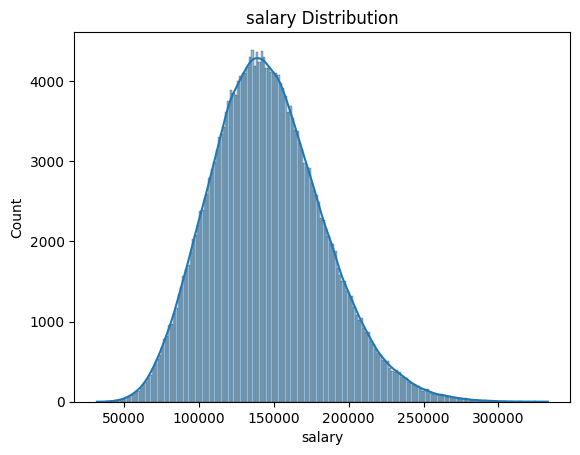

In [48]:
sns.histplot(df['salary'],kde=True)
plt.title('salary Distribution')
plt.show()

# bivariate analysis

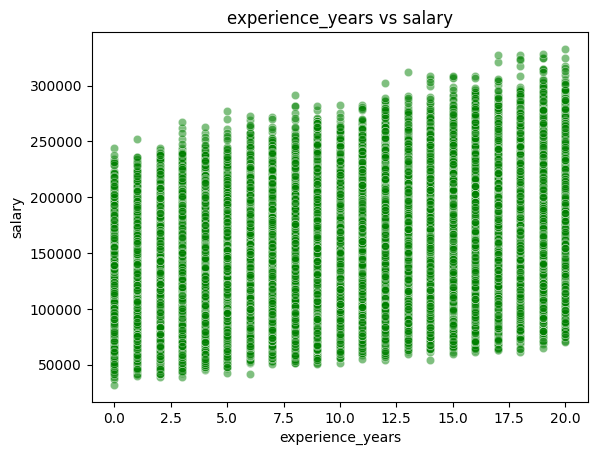

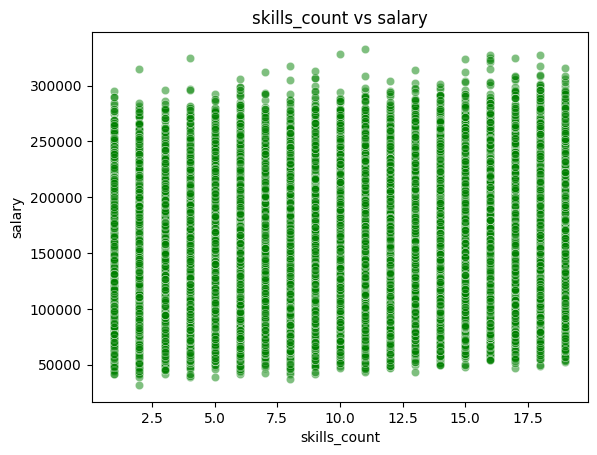

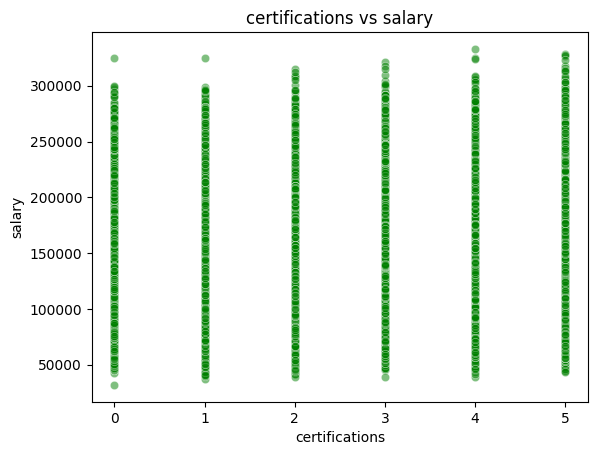

In [49]:
# numerical vs target
for col in num_cols:
    if col !='salary':
        plt.Figure(figsize=(6,3))
        sns.scatterplot(x=df[col],y=df['salary'],color='green',alpha=0.5)
        plt.title(f'{col} vs salary')
        plt.show()

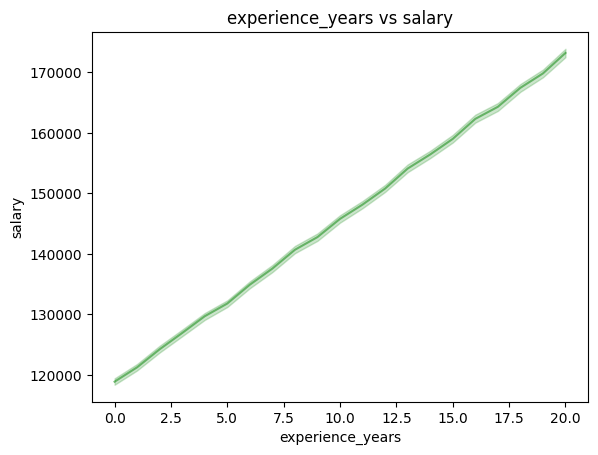

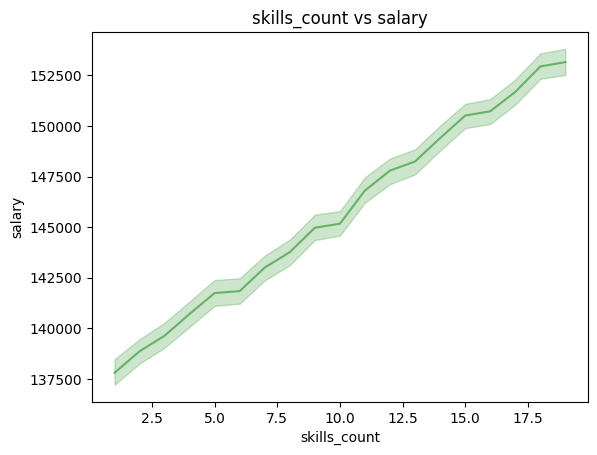

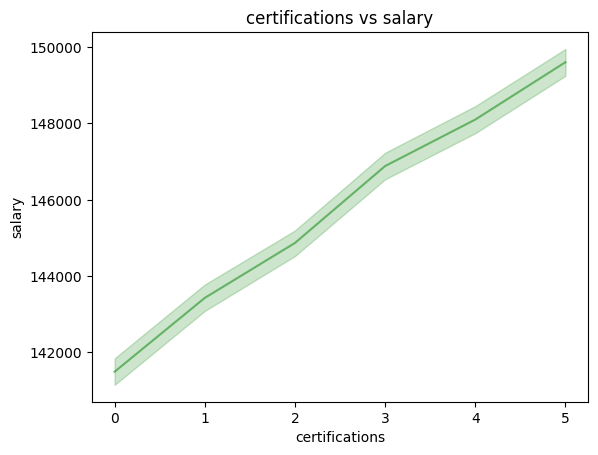

In [50]:
for col in num_cols:
    if col !='salary':
        plt.Figure(figsize=(6,3))
        sns.lineplot(x=df[col],y=df['salary'],color='green',alpha=0.5)
        plt.title(f'{col} vs salary')
        plt.show()

C:\Users\kiran\AppData\Local\Temp\ipykernel_2748\1098010350.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col],y=df['salary'],palette='rainbow')


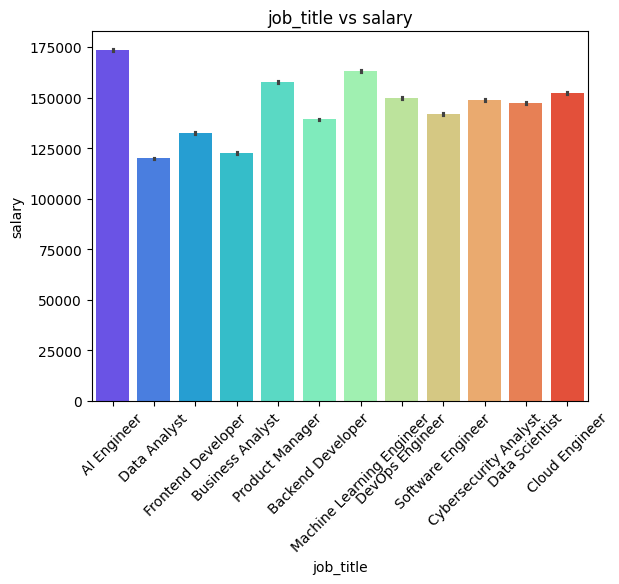

C:\Users\kiran\AppData\Local\Temp\ipykernel_2748\1098010350.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col],y=df['salary'],palette='rainbow')


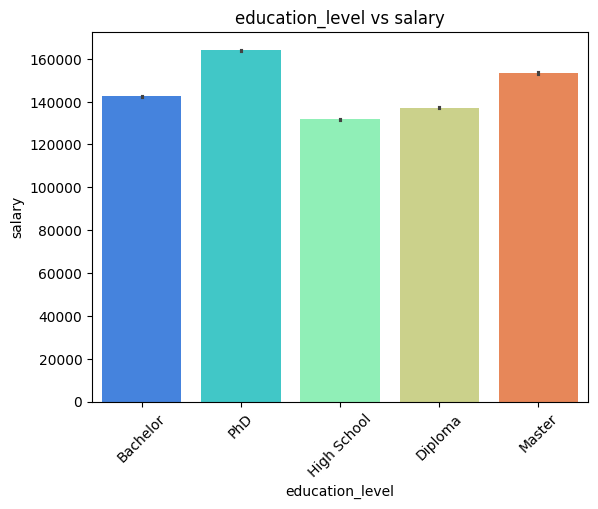

C:\Users\kiran\AppData\Local\Temp\ipykernel_2748\1098010350.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col],y=df['salary'],palette='rainbow')


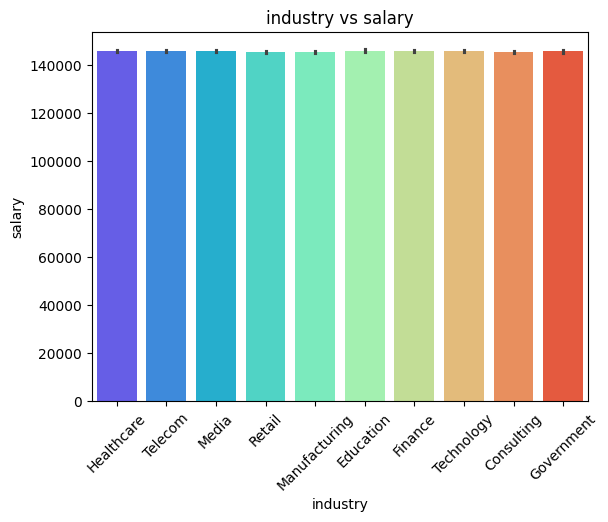

C:\Users\kiran\AppData\Local\Temp\ipykernel_2748\1098010350.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col],y=df['salary'],palette='rainbow')


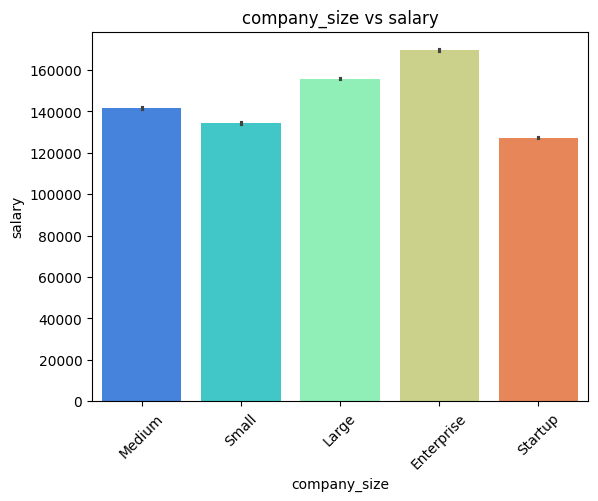

C:\Users\kiran\AppData\Local\Temp\ipykernel_2748\1098010350.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col],y=df['salary'],palette='rainbow')


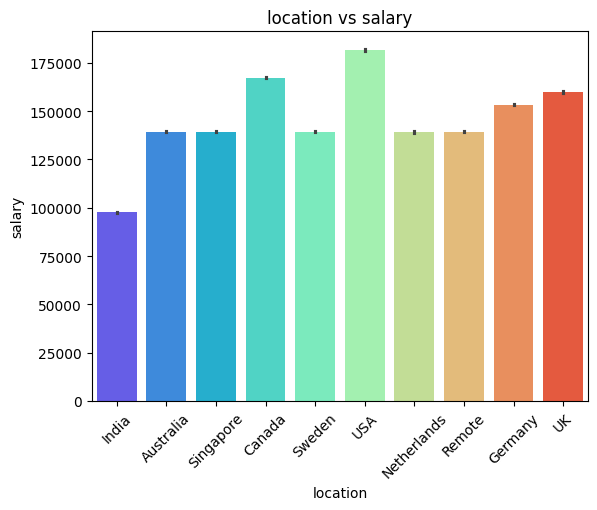

C:\Users\kiran\AppData\Local\Temp\ipykernel_2748\1098010350.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col],y=df['salary'],palette='rainbow')


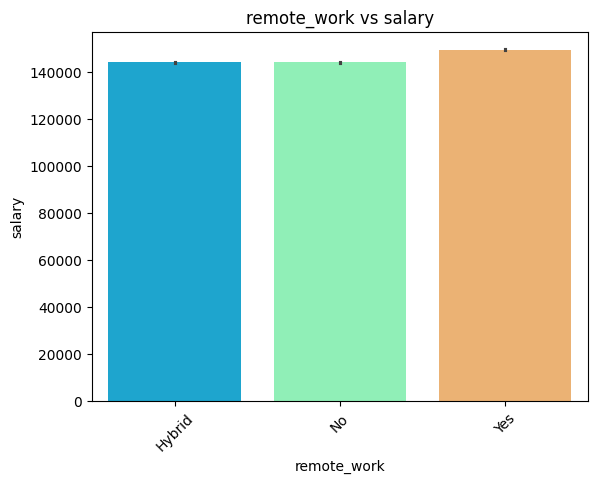

In [51]:
# categerical vs target

for col in cate_cols:
        plt.Figure(figsize=(6,3))
        sns.barplot(x=df[col],y=df['salary'],palette='rainbow')
        plt.title(f'{col} vs salary')
        plt.xticks(rotation=45)
        plt.show()

# multivariate

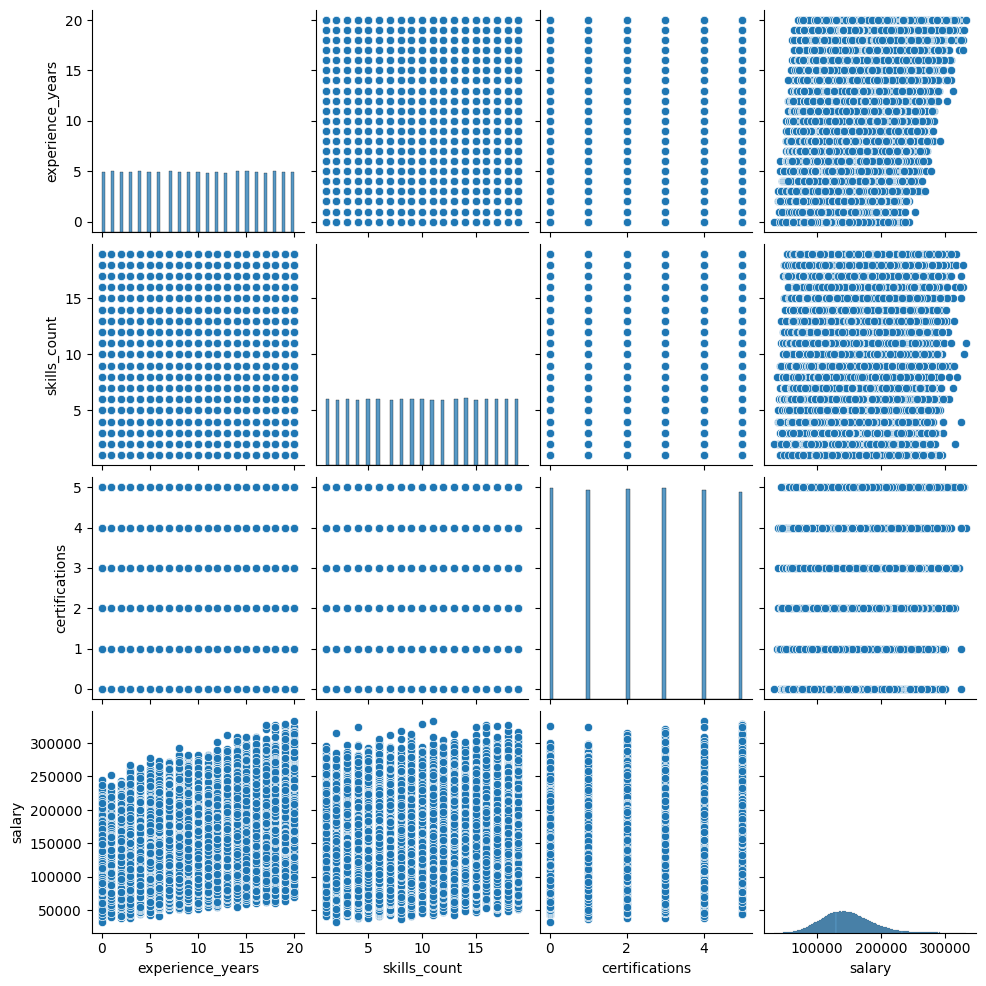

In [52]:
sns.pairplot(df[num_cols])
plt.show()

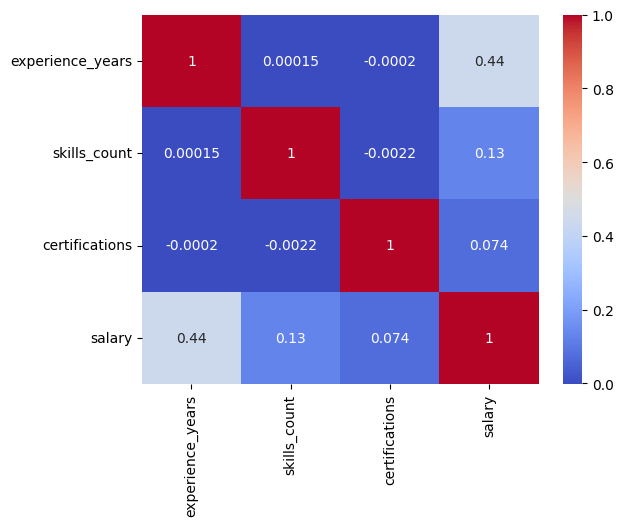

In [53]:
# Correlation heatmap

plt.Figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

# Feature selection

In [54]:
# Define target
target='salary'

# SPLIT FEATURES AND TARGET
x=df.drop(columns=[target])
y=df[target]

#seperate column types
num_cols=x.select_dtypes(include=['int64','float64']).columnscat_cols=x.select_dtypes(include=['str']).columns
print("numberical:",num_cols)
print("categorical:",cate_cols)

numberical: Index(['job_title', 'education_level', 'industry', 'company_size', 'location',
       'remote_work'],
      dtype='str')
categorical: Index(['job_title', 'education_level', 'industry', 'company_size', 'location',
       'remote_work'],
      dtype='str')


C:\Users\kiran\AppData\Local\Temp\ipykernel_2748\2516848104.py:9: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  num_cols=x.select_dtypes(include=['int64','float64']).columnscat_cols=x.select_dtypes(include=['str']).columns


# train test split 

In [55]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [56]:
cate_cols

Index(['job_title', 'education_level', 'industry', 'company_size', 'location',
       'remote_work'],
      dtype='str')

In [57]:
num_cols=df.select_dtypes(include=['int64','float']).columns

In [58]:
num_col=num_cols.drop(['salary'])

## Scaling

In [59]:
scaler=StandardScaler()

x_train_num=scaler.fit_transform(x_train[num_col])
x_test_num=scaler.transform(x_test[num_col])

x_train_num=pd.DataFrame(x_train_num,columns=num_col,index=x_train.index)
x_test_num=pd.DataFrame(x_test_num,columns=num_col,index=x_test.index)
print(x_test_num)
print(x_train_num)

        experience_years  skills_count  certifications
38683           0.163988     -0.547793        0.296761
64939          -0.496068      0.730405       -0.874320
3954           -0.001026     -1.460791        1.467841
120374         -0.331054     -0.182593        0.882301
172861         -1.321138      0.365206        0.882301
...                  ...           ...             ...
179545          0.329001     -1.095591        0.882301
222647          0.659029     -0.730392       -0.874320
171823          0.494015      0.182606        1.467841
135782          0.824043      1.278204       -0.874320
208380         -1.486151     -1.095591       -1.459860

[50000 rows x 3 columns]
        experience_years  skills_count  certifications
75381          -0.991110      0.730405        1.467841
65569          -1.486151     -0.730392       -0.874320
163473          0.989057     -1.278191       -0.874320
90518          -0.991110      1.460804        0.882301
138866         -0.496068     -0.365193 

# Ordinal Encoding

In [60]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [61]:
df.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='str')

In [62]:
df['company_size'].value_counts()

company_size
Large         50254
Small         50235
Medium        50027
Enterprise    49875
Startup       49609
Name: count, dtype: int64

In [63]:
ordinal_cols=['education_level','company_size']

ordinal_order=[['High School','Diploma','Bachelor','Master','PhD'],
               ['Small','Medium','High','Enterprise','Startup ']
]
ordinal_encorder=OrdinalEncoder(categories=ordinal_order,handle_unknown='use_encoded_value',unknown_value=-1)

x_train_ord=ordinal_encorder.fit_transform(x_train[ordinal_cols])
x_test_ord=ordinal_encorder.transform(x_test[ordinal_cols])


x_train_ord = pd.DataFrame(x_train_ord, columns=ordinal_cols, index=x_train.index)
x_test_ord = pd.DataFrame(x_test_ord, columns=ordinal_cols, index=x_test.index)

# One Hot Encoding

In [64]:
nominal_cols=[
'industry',
'location',
'remote_work'
]
ohe=OneHotEncoder(handle_unknown='ignore',
sparse_output=False)
x_train_nom=ohe.fit_transform(x_train[nominal_cols])
x_test_nom=ohe.transform(x_test[nominal_cols])
nom_cols_encoded=ohe.get_feature_names_out(nominal_cols)

x_train_nom=pd.DataFrame(x_train_nom,columns=nom_cols_encoded,index=x_train.index)
x_test_nom=pd.DataFrame(x_test_nom,columns=nom_cols_encoded,index=x_test.index)

# Label Encoding

In [65]:
label_cols = ['job_title']
label_encoders = {}
for col in label_cols:
    le = LabelEncoder()
    x_train[col] = le.fit_transform(x_train[col])
    x_test[col] = le.transform(x_test[col])
    
    label_encoders[col] = le

In [66]:
x_train_final=pd.concat([x_train_num,x_train_ord,x_train_nom],axis=1)
x_test_final=pd.concat([x_test_num,x_test_ord,x_test_nom],axis=1)

In [67]:
x_train_final.select_dtypes(include=['object']).columns

Index([], dtype='str')

In [68]:
model=LinearRegression()
model.fit(x_train_final,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [69]:
y_pred=model.predict(x_test_final)

In [70]:
print("R2Score:",r2_score(y_test,y_pred))

R2Score: 0.7049125479165794


In [71]:
y_pred=model.predict(x_test_final)
print(y_pred[:10])

[156760.16463815  94129.99958817  88578.84912699 151830.01326042
 102320.44696251 156483.05818932 129419.82354414  55116.88173293
 130912.60177804 171394.97192155]


In [ ]:
## New Dataframe

In [75]:
new_data=pd.DataFrame({

    'job_title':['Product Manager'],
    'experience_years':[3],
    'education_level':['PhD'],
    'skills_count':[6],
    'industry':['Telecom'],
    'company_size':['Small'],
    'location':['India'],
    'remote_work':['No'],
    'certifications':[2],
    'salary':[15322,]

})

In [79]:
ordinal_encorder=OrdinalEncoder(categories=ordinal_order,handle_unknown='use_encoded_value',unknown_value=-1)

In [83]:
ordinal_encorder.fit(x_train[['education_level', 'company_size']])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.","[['High School', 'Diploma', ...], ['Small', 'Medium', ...]]"
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'use_encoded_value'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",-1
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None
,"max_categories max_categories: int, default=NoneSpecifies an upper limit to the number of output categories for each inputfeature when considering infrequent categories. If there are infrequentcategories, `max_categories` includes the category representing theinfrequent categories along with the frequent categories. If `None`,there is no limit to the number of output features.`max_categories` do **not** take into account missing or unknowncategories. Setting `unknown_value` or `encoded_missing_value` to aninteger will increase the number of unique integer codes by one each.This can result in up to `max_categories + 2` integer codes... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None


In [84]:
new_ord=ordinal_encorder.transform(new_data[['education_level','company_size']])
new_ord=pd.DataFrame(new_ord,columns=['education_level','company_size'])

In [89]:
new_num=scaler.transform(new_data[num_col])
new_num=pd.DataFrame(new_num,columns=num_col)

In [90]:
new_nom=ohe.transform(new_data[nominal_cols])
new_nom=pd.DataFrame(new_nom,columns=nom_cols_encoded)

In [91]:
new_final=pd.concat([new_num,new_ord,new_nom],axis=1)

In [93]:
prediction=model.predict(new_final)
print("Predicted Salary:",prediction[0].round(2))

Predicted Salary: 86017.17
